In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from scipy.integrate import simpson as simps
import os

from scipy.integrate import trapezoid

from scipy.interpolate import Akima1DInterpolator

from scipy.interpolate import PchipInterpolator

In [2]:
xs_data = pd.read_excel('F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\XS_Data_ID81.xlsx')
xs_data.head(10)

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\rbe\AppData\Local\Temp\ipykernel_21960\580217971.py:1: SyntaxWarning: invalid escape sequence '\P'
  xs_data = pd.read_excel('F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\XS_Data_ID81.xlsx')


,Distance,RL_mMSL
0,0,11.029
1,7,11.037
2,13,10.987
3,18,10.829
4,25,10.760
5,30,10.605
6,31,10.452
7,34,9.675
8,36,9.297
9,37,8.876


# Plot XS

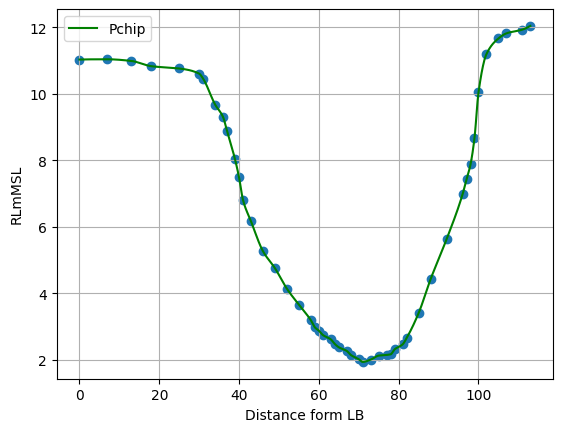

In [3]:
x = xs_data['Distance']
y = xs_data['RL_mMSL']

# Interpolate finer resolution
x_dense = np.linspace(x.min(), x.max(), 1000)
# f_qurd = interp1d(x, y, kind='quadratic')   # Not Suitable for river
# y_qurd = f_qurd(x_dense)

f_php = PchipInterpolator(x, y)               # Best for XS Interpolation
y_php = f_php(x_dense)

# f_akima = Akima1DInterpolator(x, y)           # Better for XS Interpolation
# y_akima = f_akima(x_dense)

plt.scatter(xs_data['Distance'],xs_data['RL_mMSL'])
# plt.plot(x_dense,y_qurd,color = 'red',linestyle = '-', label='Qurdatric')
plt.plot(x_dense,y_php,color = 'green',linestyle = '-', label='Pchip')
#plt.plot(x_dense,y_akima,color = 'blue',linestyle = '-', label='Akima')
plt.legend()
plt.grid()
plt.xlabel('Distance form LB')
plt.ylabel('RLmMSL')
plt.show()

# Load WL Data

In [4]:
import pandas as pd

file_path = r'F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\WL_Data_All_Flood_Event_Year.xlsx'

# Read all sheets into a dictionary
dfs = pd.read_excel(file_path, sheet_name=None)

# Convert Date column in each sheet
for name, df in dfs.items():
    df['Date'] = pd.to_datetime(df['Date'])

# Access individual sheets
WL_1988_100yr = dfs['1988 100yr']
WL_2017_50yr  = dfs['2017 50yr']
WL_2004_25yr  = dfs['2004 25yr']
WL_2008_2_33yr = dfs['2008 2.33yr']
WL_2020_Clib = dfs['Calibration 2020']

WL_1988_100yr.head()


,Date,WL_mMSL_Original,WL_mMSL
0,1988-01-01 12:00:00,4.48,4.53
1,1988-01-02 12:00:00,4.54,4.59
2,1988-01-03 12:00:00,4.53,4.58
3,1988-01-04 12:00:00,4.52,4.57
4,1988-01-05 12:00:00,4.51,4.56


# Plot All Data

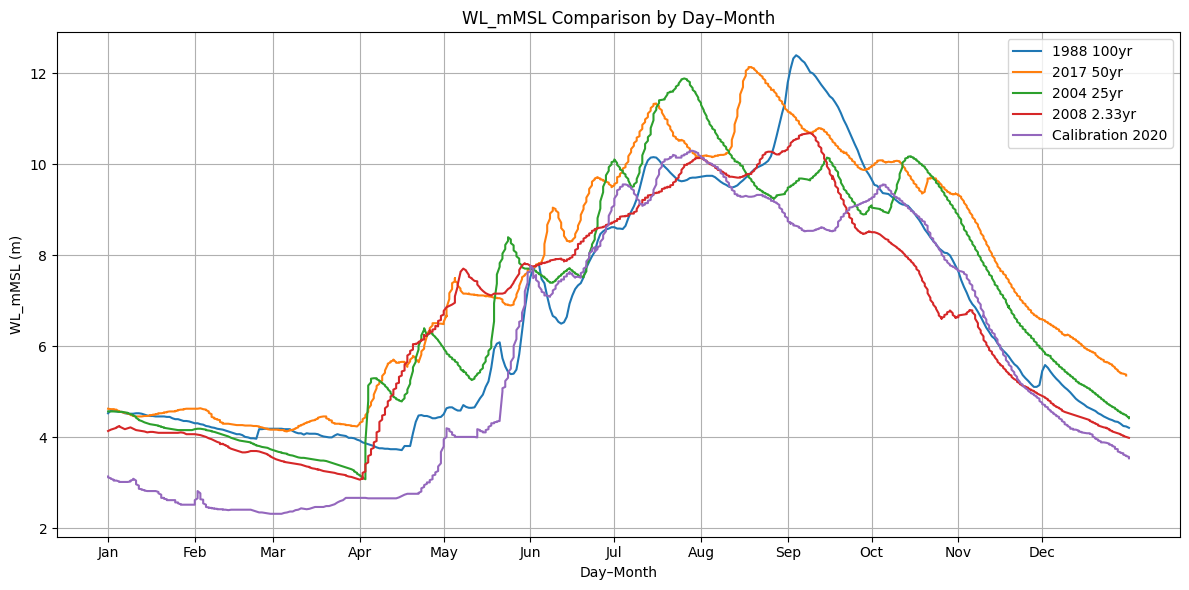

In [5]:
for df in [WL_1988_100yr, WL_2017_50yr, WL_2004_25yr, WL_2008_2_33yr, WL_2020_Clib]:
    df['DOY'] = df['Date'].dt.dayofyear

plt.figure(figsize=(12, 6))

plt.plot(WL_1988_100yr['DOY'], WL_1988_100yr['WL_mMSL'], label='1988 100yr')
plt.plot(WL_2017_50yr['DOY'],  WL_2017_50yr['WL_mMSL'],  label='2017 50yr')
plt.plot(WL_2004_25yr['DOY'],  WL_2004_25yr['WL_mMSL'],  label='2004 25yr')
plt.plot(WL_2008_2_33yr['DOY'],WL_2008_2_33yr['WL_mMSL'],label='2008 2.33yr')
plt.plot(WL_2020_Clib['DOY'],  WL_2020_Clib['WL_mMSL'],  label='Calibration 2020')

plt.xlabel('Day–Month')
plt.ylabel('WL_mMSL (m)')
plt.title('WL_mMSL Comparison by Day–Month')
plt.legend()
plt.grid(True)

# Month labels
month_starts = pd.date_range('2001-01-01', '2001-12-01', freq='MS')
plt.xticks(
    month_starts.dayofyear,
    month_starts.strftime('%b')
)

plt.tight_layout()
plt.show()


# Add Observed Data

In [6]:
Observed_Q_2020 = pd.read_excel('F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\Observed Q 2020 BWDB.xlsx')
Observed_Q_2020['Date'] = pd.to_datetime(Observed_Q_2020['Date'],dayfirst=True)

Observed_Q_2017 = pd.read_excel('F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\Observed Q 2017 BWDB.xlsx')
Observed_Q_2017['Date'] = pd.to_datetime(Observed_Q_2017['Date'],dayfirst=True)

Observed_Q_2004 = pd.read_excel('F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\Observed Q 2004 BWDB.xlsx')
Observed_Q_2004['Date'] = pd.to_datetime(Observed_Q_2004['Date'],dayfirst=True)

Observed_Q_2020.head(10)

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:4: SyntaxWarning: invalid escape sequence '\P'
<>:7: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:4: SyntaxWarning: invalid escape sequence '\P'
<>:7: SyntaxWarning: invalid escape sequence '\P'
C:\Users\rbe\AppData\Local\Temp\ipykernel_21960\3508476008.py:1: SyntaxWarning: invalid escape sequence '\P'
  Observed_Q_2020 = pd.read_excel('F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\Observed Q 2020 BWDB.xlsx')
C:\Users\rbe\AppData\Local\Temp\ipykernel_21960\3508476008.py:4: SyntaxWarning: invalid escape sequence '\P'
  Observed_Q_2017 = pd.read_excel('F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\Observed Q 2017 BWDB.xlsx')
C:\Users\rbe\AppData\Local\Temp\ipykernel_21960\3508476008.py:7: SyntaxWarning: invalid escape sequence '\P'
  Observed_Q_2004 = pd.read_excel('F:\P-529990 Joydeppur Iswardi Double Rail Line

,Date,WL_mMSL,Observed_Q
0,2020-07-02,9.36,48.09
1,2020-07-16,9.71,54.44
2,2020-07-20,10.05,66.05
3,2020-07-30,10.12,73.40
4,2020-08-13,9.21,58.22
5,2020-08-27,9.05,54.64
6,2020-09-10,8.46,47.29
7,2020-09-24,8.98,51.78
8,2020-10-04,9.45,59.77
9,2020-10-08,9.19,54.99


# Interpolate WL Calibration Year

C:\Users\rbe\AppData\Local\Temp\ipykernel_21960\2381027314.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')


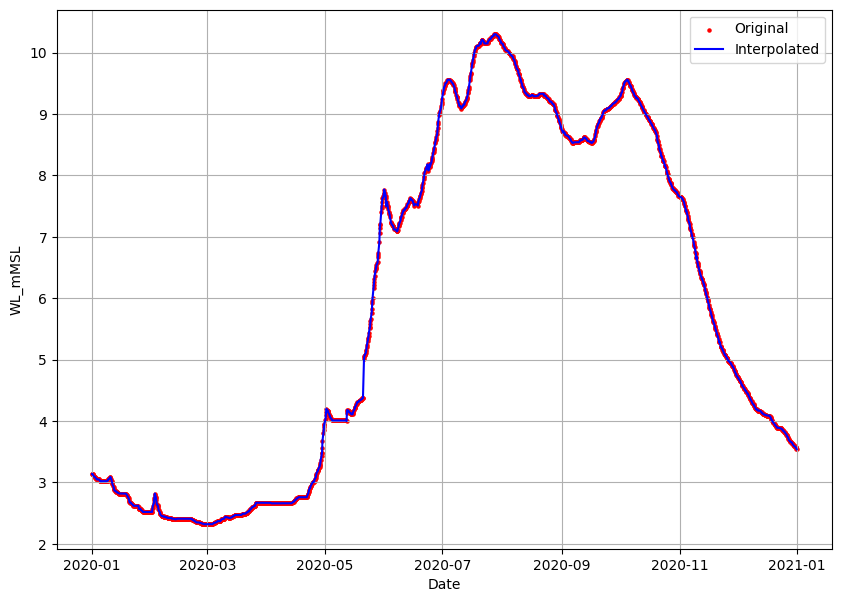

In [7]:
WL_2020_Clib['Date'] = pd.to_datetime(WL_2020_Clib['Date'])
df = WL_2020_Clib.copy()

# Create interpolated column (same initial values)
df['Interpolated_WL_mMSL'] = df['WL_mMSL']

# Set Date as index
df.set_index('Date', inplace=True)

# Full hourly range
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')
df_full = df.reindex(full_range)

# Interpolate ONLY the interpolated column
df_full['Interpolated_WL_mMSL'] = df_full['Interpolated_WL_mMSL'].interpolate(method='linear')

# Reset index
df_full.reset_index(inplace=True)
df_full.rename(columns={'index': 'Date'}, inplace=True)

df_full.head()

plt.figure(figsize=(10, 7))

# Original data (no interpolation)
plt.scatter(
    WL_2020_Clib['Date'],
    WL_2020_Clib['WL_mMSL'],
    label='Original',
    s=5,
    color='red'
)

# Interpolated data
plt.plot(
    df_full['Date'],
    df_full['Interpolated_WL_mMSL'],
    label='Interpolated',
    color='blue'
)

plt.legend()
plt.grid()
plt.xlabel('Date')
plt.ylabel('WL_mMSL')
plt.show()

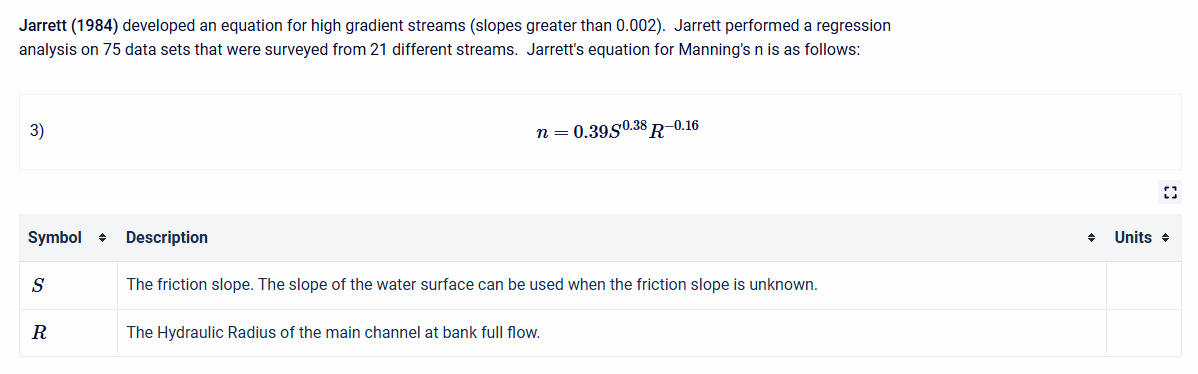

# Calculate Discharge Calibration Year


0.1833804692148988
70.81028229608515
Max WL 10.3


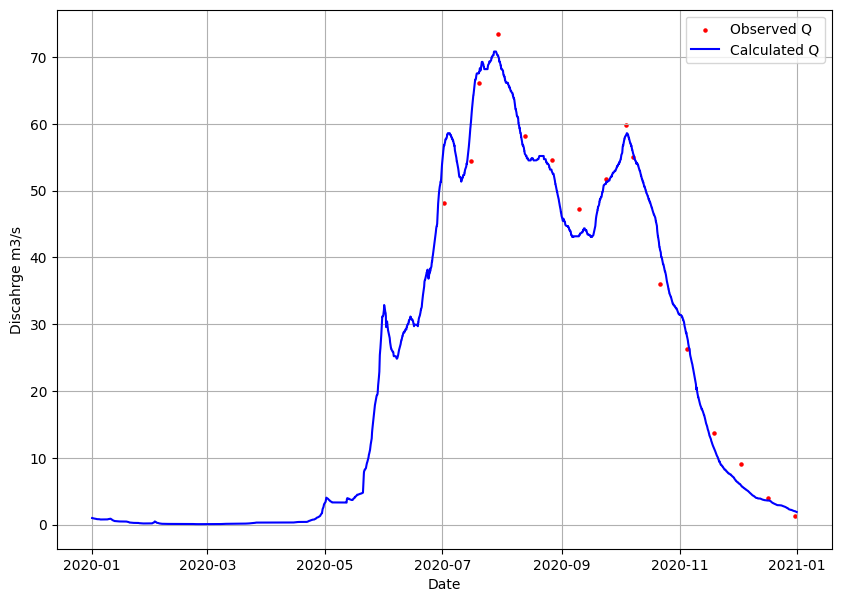

In [13]:
WL = df_full
y_dense = y_php
x_dense = np.linspace(x.min(), x.max(), 1000)
n_manning = 0.075
S = 0.00002
results = []

for _, row in WL.iterrows():
    date = row['Date']
    water_level = row['Interpolated_WL_mMSL']

    submerged = y_dense < water_level
    x_sub = x_dense[submerged]
    y_sub = y_dense[submerged]

    if len(x_sub) < 2:
        area = 0
        wetted_perimeter = 0
        hydraulic_radius = 0
        velocity = 0
        discharge = 0
    else:
        water_depth = water_level - y_sub
        area = trapezoid(water_depth, x_sub)
        dx = np.diff(x_sub)
        dy = np.diff(y_sub)
        segment_lengths = np.sqrt(dx**2 + dy**2)
        wetted_perimeter = np.sum(segment_lengths)
        hydraulic_radius = area / wetted_perimeter if wetted_perimeter > 0 else 0
        # n_manning = 0.39*(hydraulic_radius)**(0.16) * (S**0.38)  # Jarrett (1984)
        velocity = (1 / n_manning) * (hydraulic_radius**(2/3)) * (S**0.5) if hydraulic_radius > 0 else 0
        discharge = velocity * area

    results.append({
        'Date': date,
        'WLmMSL': water_level,
        'Area': area,
        'Wetted_Perimeter': wetted_perimeter,
        'Hydraulic_Radius': hydraulic_radius,
        'n_manning': n_manning,
        'Velocity': velocity,
        'Discharge': discharge
    })

Calculated_Discharge = pd.DataFrame(results)
Calculated_Discharge['Date'] = pd.to_datetime(Calculated_Discharge['Date'])
print(Calculated_Discharge['Velocity'].max())
print(Calculated_Discharge['Discharge'].max())
print('Max WL', df_full['Interpolated_WL_mMSL'].max())
Calculated_Discharge.head()

plt.figure(figsize=(10, 7))

# Original data (no interpolation)
plt.scatter(
    Observed_Q_2020['Date'],
    Observed_Q_2020['Observed_Q'],
    label='Observed Q',
    s=5,
    color='red'
)

# Interpolated data
plt.plot(
    Calculated_Discharge['Date'],
    Calculated_Discharge['Discharge'],
    label='Calculated Q',
    color='blue'
)

plt.legend()
plt.grid()
plt.xlabel('Date')
plt.ylabel('Discahrge m3/s')
plt.show()

In [129]:
Calculated_Discharge.to_csv('Calculated Discharge 2020_F.csv', index=False)

# Interpolate WL  Year 2017

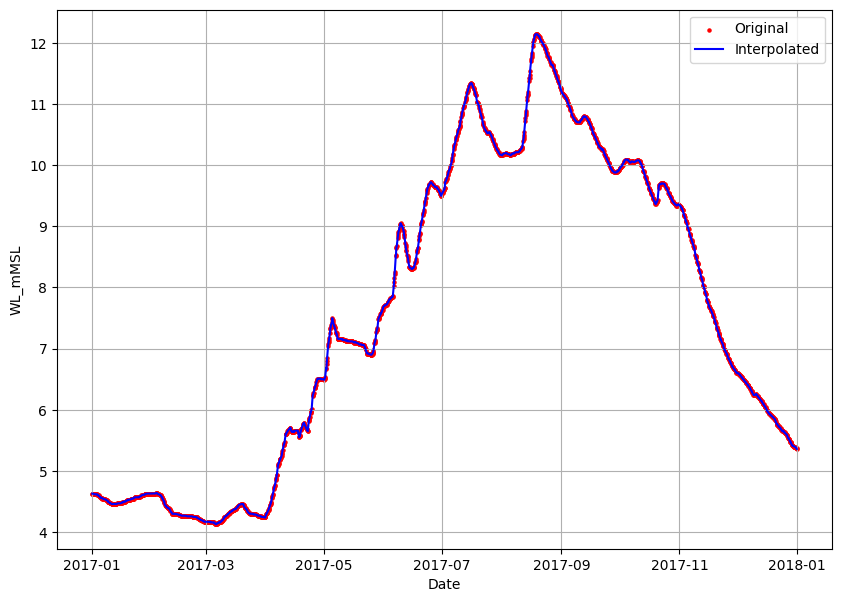

In [14]:
WL_2017_50yr['Date'] = pd.to_datetime(WL_2017_50yr['Date'])
df_2017 = WL_2017_50yr.copy()

# Create interpolated column (same initial values)
df_2017['Interpolated_WL_mMSL'] = df_2017['WL_mMSL']

# Set Date as index
df_2017.set_index('Date', inplace=True)

# Full hourly range
full_range_2017 = pd.date_range(start=df_2017.index.min(), end=df_2017.index.max(), freq='h')
df_full_2017 = df_2017.reindex(full_range_2017)

# Interpolate ONLY the interpolated column
df_full_2017['Interpolated_WL_mMSL'] = df_full_2017['Interpolated_WL_mMSL'].interpolate(method='linear')

# Reset index
df_full_2017.reset_index(inplace=True)
df_full_2017.rename(columns={'index': 'Date'}, inplace=True)

df_full_2017.head()

plt.figure(figsize=(10, 7))

# Original data (no interpolation)
plt.scatter(
    WL_2017_50yr['Date'],
    WL_2017_50yr['WL_mMSL'],
    label='Original',
    s=5,
    color='red'
)

# Interpolated data
plt.plot(
    df_full_2017['Date'],
    df_full_2017['Interpolated_WL_mMSL'],
    label='Interpolated',
    color='blue'
)

plt.legend()
plt.grid()
plt.xlabel('Date')
plt.ylabel('WL_mMSL')
plt.show()

# Calculate Discharge  Year 2017


0.18611692548803146
94.77734927346685
Max WL 12.14


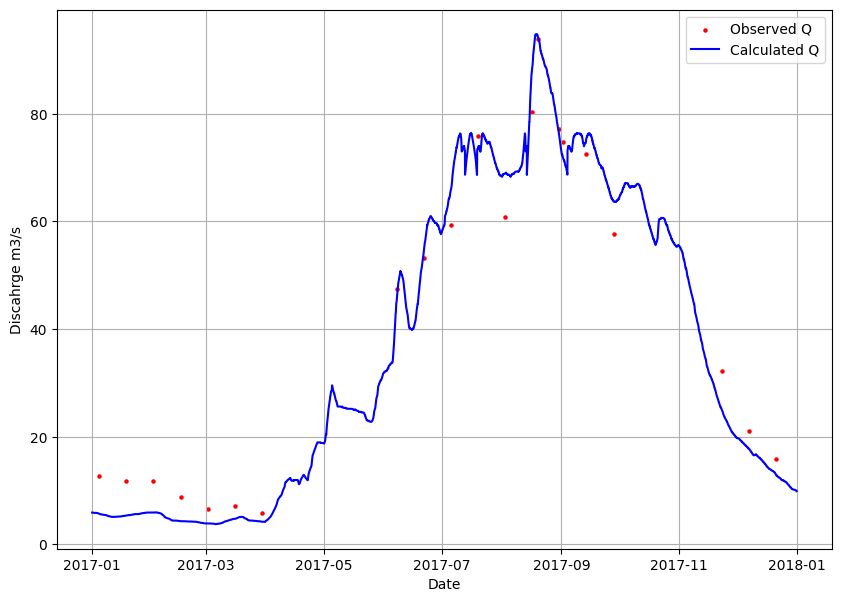

In [15]:
WL_2017 = df_full_2017
y_dense = y_php
x_dense = np.linspace(x.min(), x.max(), 1000)
n_manning = 0.075
S = 0.00002
results = []

for _, row in WL_2017.iterrows():
    date = row['Date']
    water_level = row['Interpolated_WL_mMSL']

    submerged = y_dense < water_level
    x_sub = x_dense[submerged]
    y_sub = y_dense[submerged]

    if len(x_sub) < 2:
        area = 0
        wetted_perimeter = 0
        hydraulic_radius = 0
        velocity = 0
        discharge = 0
    else:
        water_depth = water_level - y_sub
        area = trapezoid(water_depth, x_sub)

        dx = np.diff(x_sub)
        dy = np.diff(y_sub)

        segment_lengths = np.sqrt(dx**2 + dy**2)
        wetted_perimeter = np.sum(segment_lengths)

        hydraulic_radius = area / wetted_perimeter if wetted_perimeter > 0 else 0

        # n_manning = 02.5*(hydraulic_radius*3.28)**(0.16) * (S**0.38)  # Jarrett (1984)

        velocity = (1 / n_manning) * (hydraulic_radius**(2/3)) * (S**0.5) if hydraulic_radius > 0 else 0

        discharge = velocity * area

    results.append({
        'Date': date,
        'WLmMSL': water_level,
        'Area': area,
        'Wetted_Perimeter': wetted_perimeter,
        'Hydraulic_Radius': hydraulic_radius,
        'n_manning': n_manning,
        'Velocity': velocity,
        'Discharge': discharge
    })

Calculated_Discharge_2017 = pd.DataFrame(results)
Calculated_Discharge_2017['Date'] = pd.to_datetime(Calculated_Discharge_2017['Date'])
print(Calculated_Discharge_2017['Velocity'].max())
print(Calculated_Discharge_2017['Discharge'].max())
print('Max WL',df_full_2017['Interpolated_WL_mMSL'].max())
Calculated_Discharge_2017.head()

plt.figure(figsize=(10, 7))

# Original data (no interpolation)
plt.scatter(
    Observed_Q_2017['Date'],
    Observed_Q_2017['Observed_Q'],
    label='Observed Q',
    s=5,
    color='red'
)

# Interpolated data
plt.plot(
    Calculated_Discharge_2017['Date'],
    Calculated_Discharge_2017['Discharge'],
    label='Calculated Q',
    color='blue'
)

plt.legend()
plt.grid()
plt.xlabel('Date')
plt.ylabel('Discahrge m3/s')
plt.show()

# Interpolate WL  Year 2004

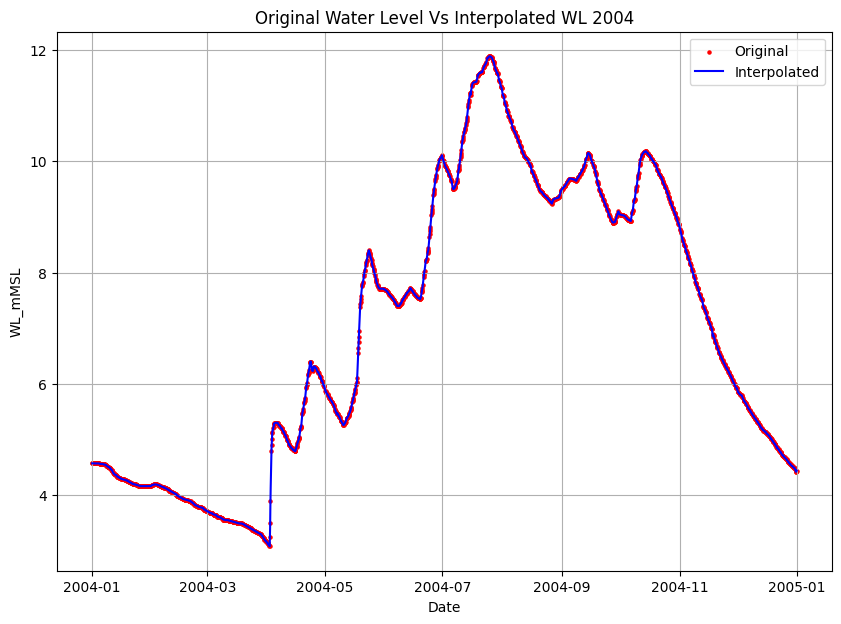

In [16]:
WL_2004_25yr['Date'] = pd.to_datetime(WL_2004_25yr['Date'])
wl_2004 = WL_2004_25yr.copy()

# Create interpolated column (same initial values)
wl_2004['Interpolated_WL_mMSL'] = wl_2004['WL_mMSL']

# Set Date as index
wl_2004.set_index('Date', inplace=True)

# Full hourly range
full_range_2004 = pd.date_range(start=wl_2004.index.min(), end=wl_2004.index.max(), freq='h')
df_full_2004 = wl_2004.reindex(full_range_2004)

# Interpolate ONLY the interpolated column
df_full_2004['Interpolated_WL_mMSL'] = df_full_2004['Interpolated_WL_mMSL'].interpolate(method='linear')

# Reset index
df_full_2004.reset_index(inplace=True)
df_full_2004.rename(columns={'index': 'Date'}, inplace=True)

df_full_2004.head()

plt.figure(figsize=(10, 7))

# Original data (no interpolation)
plt.scatter(
    WL_2004_25yr['Date'],
    WL_2004_25yr['WL_mMSL'],
    label='Original',
    s=5,
    color='red'
)

# Interpolated data
plt.plot(
    df_full_2004['Date'],
    df_full_2004['Interpolated_WL_mMSL'],
    label='Interpolated',
    color='blue'
)

plt.legend()
plt.grid()
plt.title('Original Water Level Vs Interpolated WL 2004')
plt.xlabel('Date')
plt.ylabel('WL_mMSL')
plt.show()

# Calculate Discharge  Year 2004


Max Velocity 0.18609901479959326
Max Discharge 88.72558767893567
Max WL 11.89


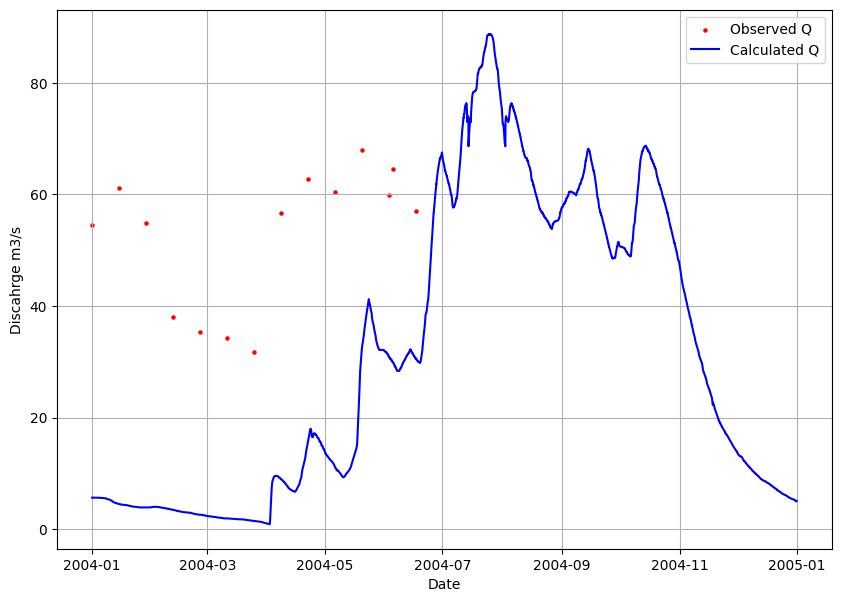

In [17]:
WL_2004 = df_full_2004
y_dense = y_php
x_dense = np.linspace(x.min(), x.max(), 1000)
n_manning = 0.075
S = 0.00002
results = []

for _, row in WL_2004.iterrows():
    date = row['Date']
    water_level = row['Interpolated_WL_mMSL']

    submerged = y_dense < water_level
    x_sub = x_dense[submerged]
    y_sub = y_dense[submerged]

    if len(x_sub) < 2:
        area = 0
        wetted_perimeter = 0
        hydraulic_radius = 0
        velocity = 0
        discharge = 0
    else:
        water_depth = water_level - y_sub
        area = trapezoid(water_depth, x_sub)

        dx = np.diff(x_sub)
        dy = np.diff(y_sub)

        segment_lengths = np.sqrt(dx**2 + dy**2)
        wetted_perimeter = np.sum(segment_lengths)

        hydraulic_radius = area / wetted_perimeter if wetted_perimeter > 0 else 0

        # n_manning = 02.5*(hydraulic_radius*3.28)**(0.16) * (S**0.38)  # Jarrett (1984)

        velocity = (1 / n_manning) * (hydraulic_radius**(2/3)) * (S**0.5) if hydraulic_radius > 0 else 0

        discharge = velocity * area

    results.append({
        'Date': date,
        'WLmMSL': water_level,
        'Area': area,
        'Wetted_Perimeter': wetted_perimeter,
        'Hydraulic_Radius': hydraulic_radius,
        'n_manning': n_manning,
        'Velocity': velocity,
        'Discharge': discharge
    })

Calculated_Discharge_2004 = pd.DataFrame(results)
Calculated_Discharge_2004['Date'] = pd.to_datetime(Calculated_Discharge_2004['Date'])
print('Max Velocity', Calculated_Discharge_2004['Velocity'].max())
print('Max Discharge',Calculated_Discharge_2004['Discharge'].max())
print('Max WL',df_full_2004['Interpolated_WL_mMSL'].max())
Calculated_Discharge_2004.head()

plt.figure(figsize=(10, 7))

# Original data (no interpolation)
plt.scatter(
    Observed_Q_2004['Date'],
    Observed_Q_2004['Observed_Q'],
    label='Observed Q',
    s=5,
    color='red'
)

# Interpolated data
plt.plot(
    Calculated_Discharge_2004['Date'],
    Calculated_Discharge_2004['Discharge'],
    label='Calculated Q',
    color='blue'
)

plt.legend()
plt.grid()
plt.xlabel('Date')
plt.ylabel('Discahrge m3/s')
plt.show()

# 100 Year Flood 1988

In [18]:
WL_1988_100yr.head()
WL_1988_100yr_f = WL_1988_100yr[['Date', 'WL_mMSL']]
WL_1988_100yr_f.head()

,Date,WL_mMSL
0,1988-01-01 12:00:00,4.53
1,1988-01-02 12:00:00,4.59
2,1988-01-03 12:00:00,4.58
3,1988-01-04 12:00:00,4.57
4,1988-01-05 12:00:00,4.56


In [67]:
Calculated_Discharge.to_csv('Calculated Discharge 2019_F.csv', index=False)

# Plotting Maximum Water Level


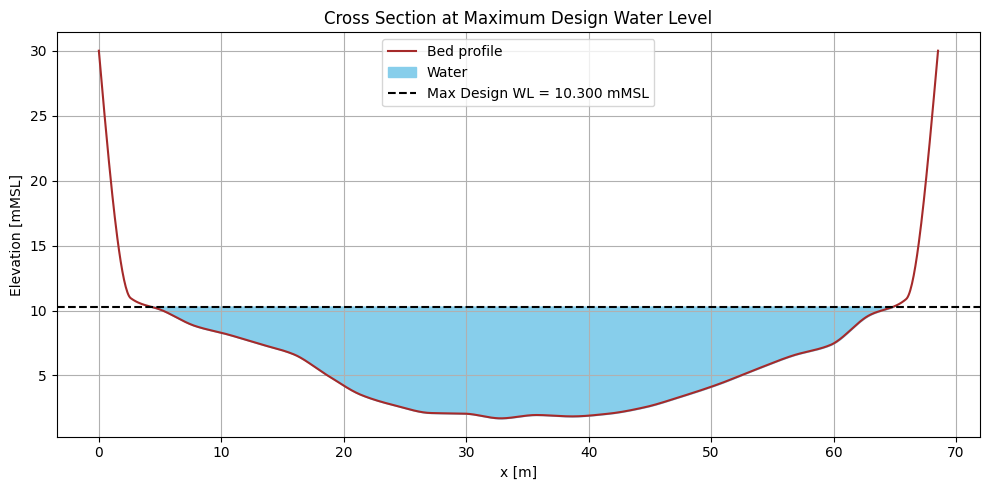

In [36]:
# Find the row with the maximum design water level
max_row = WL.loc[WL['Interpolated_WL_mMSL'].idxmax()]
max_water_level = max_row['Interpolated_WL_mMSL']

# Submerged portion of the cross section
submerged = y_dense < max_water_level
x_sub = x_dense[submerged]
y_sub = y_dense[submerged]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x_dense, y_dense, color='brown', linestyle='-', label='Bed profile')

if len(x_sub) >= 2:
    plt.fill_between(x_sub, y_sub, max_water_level, color='skyblue', label='Water')

plt.axhline(max_water_level, color='black', linestyle='--', label=f'Max Design WL = {max_water_level:.3f} mMSL')
plt.legend()
plt.xlabel("x [m]")
plt.ylabel("Elevation [mMSL]")
plt.title("Cross Section at Maximum Design Water Level")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot for any specific date

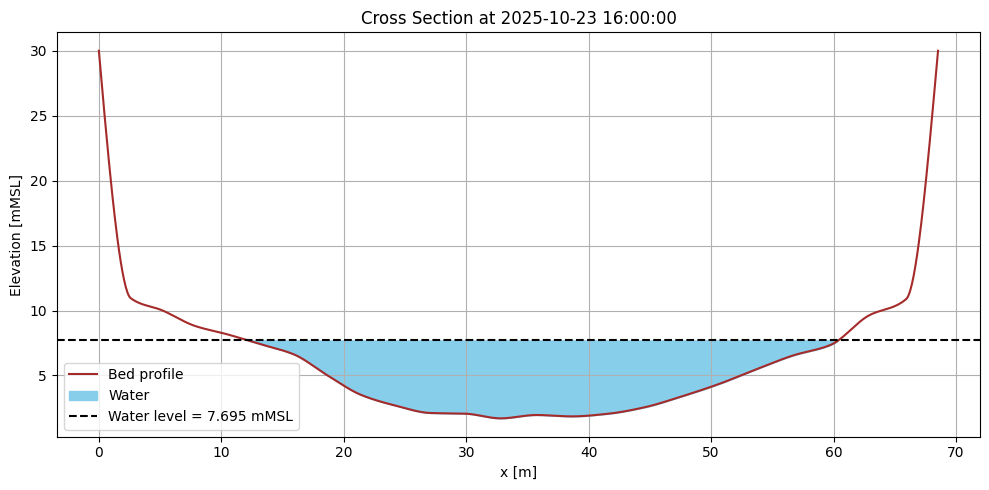

In [ ]:
# Define your target datetime (replace with any other date/time from your DataFrame)
target_datetime = '2025-10-23 16:00:00'

# Ensure the 'Date' column is datetime type
df_full['Date'] = pd.to_datetime(df_full['Date'])

# Filter the row for the specific datetime
row = df_full[df_full['Date'] == target_datetime]

if row.empty:
    print(f"No data found for {target_datetime}")
else:
    water_level = row.iloc[0]['Interpolated_WL_mMSL']

    # Geometry
    y_dense = y_php
    x_dense = np.linspace(x.min(), x.max(), 1000)

    # Submerged portion
    submerged = y_dense < water_level
    x_sub = x_dense[submerged]
    y_sub = y_dense[submerged]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(x_dense, y_dense, color='brown', linestyle='-', label='Bed profile')

    if len(x_sub) >= 2:
        plt.fill_between(x_sub, y_sub, water_level, color='skyblue', label='Water')

    plt.axhline(water_level, color='black', linestyle='--', label=f'Water level = {water_level:.3f} mMSL')
    plt.title(f"Cross Section at {target_datetime}")
    plt.xlabel("x [m]")
    plt.ylabel("Elevation [mMSL]")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

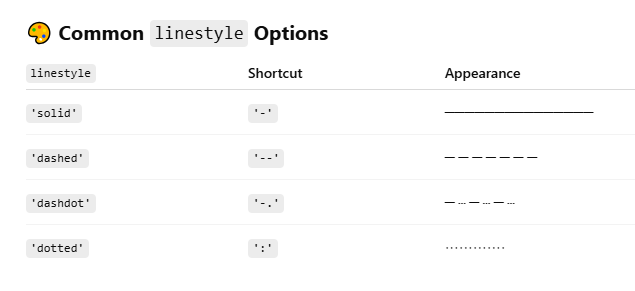

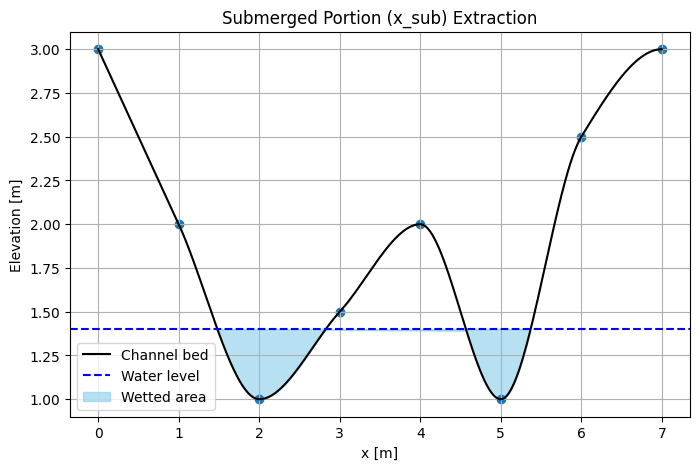

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.interpolate import Akima1DInterpolator

from scipy.interpolate import PchipInterpolator

# Define coarse cross-section
x = np.array([0, 1, 2, 3, 4, 5, 6, 7])
y = np.array([3, 2, 1, 1.5, 2, 1, 2.5, 3])  # U-shaped channel

# Interpolate to make it smooth
x_dense = np.linspace(0, 7, 500)
#f = Akima1DInterpolator(x, y)
f = PchipInterpolator(x, y)
y_dense = f(x_dense)

# Define water level
water_level = 1.4

# Extract only submerged points
submerged = y_dense < water_level         # Boolean mask
x_sub = x_dense[submerged]                # Submerged x's
y_sub = y_dense[submerged]                # Submerged y's

# Water depth at submerged points
depth = water_level - y_sub

# PLOT
plt.figure(figsize=(8, 5))
plt.plot(x_dense, y_dense, label="Channel bed", color="black")
plt.axhline(water_level, color='blue', linestyle='--', label="Water level")
plt.fill_between(x_sub, y_sub, water_level, color='skyblue', alpha=0.6, label="Wetted area")
plt.scatter(x,y)
# Mark the wetted zone edges
#if len(x_sub) > 0:
#    plt.axvline(x_sub[0], color='green', linestyle=':', label="Wetted zone start")
#    plt.axvline(x_sub[-1], color='red', linestyle=':', label="Wetted zone end")

plt.xlabel("x [m]")
plt.ylabel("Elevation [m]")
plt.title("Submerged Portion (x_sub) Extraction")
plt.legend()
plt.grid(True)
plt.show()


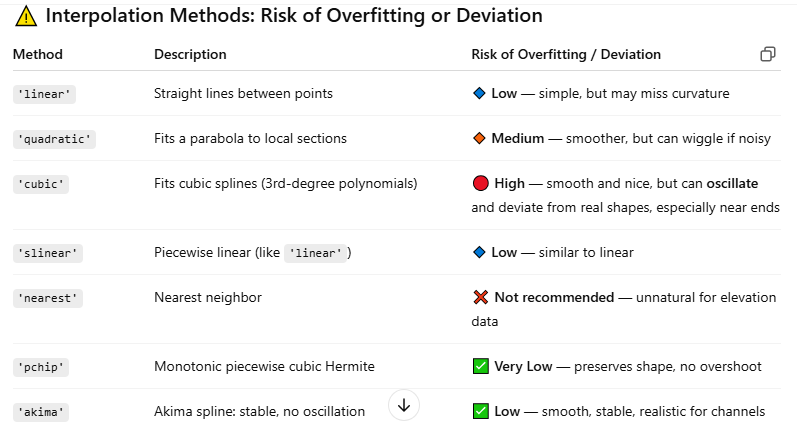

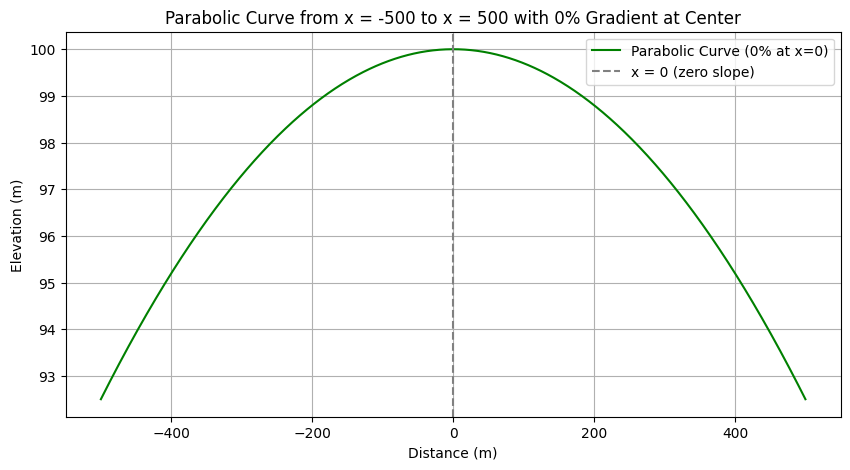

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Domain: from -500 to +500 meters
x = np.linspace(-500, 500, 1000)

# Gradient at ends (slope) = ±0.03
slope = -0.03

# Use derivative of y = ax^2 + c => y' = 2ax
# At x = 500, y' = 0.03 => a = 0.03 / (2 * 500)
a = slope / (2 * 500)

# Set vertex elevation at x = 0
c = 100  # elevation at x = 0

# Parabola equation
y = a * x**2 + c

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(x, y, label="Parabolic Curve (0% at x=0)", color='green')
plt.axvline(0, linestyle='--', color='gray', label='x = 0 (zero slope)')
plt.title("Parabolic Curve from x = -500 to x = 500 with 0% Gradient at Center")
plt.xlabel("Distance (m)")
plt.ylabel("Elevation (m)")
plt.grid(True)
plt.legend()
plt.show()
